In [1]:
import pandas as pd
import numpy as np

In [2]:
# SFMS
slope = 0.86
intercept=-8.5
def del_SFMS(Mstar, SFR):
    SFMS = slope * Mstar + intercept
    del_SFMS = SFR - SFMS
    return del_SFMS

def is_quenched(del_SFMS):
    if del_SFMS < -0.5:
        return True
    else:
        return False

In [3]:
# low_mass_satellite_df = pd.read_parquet ('low_mass_satellite_df.parquet')
low_mass_satellite_df = pd.read_parquet ('../../data/low_mass_satellite_df_annuli_revised.parquet')
print('length of low- mass satellites df:', len(low_mass_satellite_df))

# --- remove quenched galaxies using del_SFMS and is_quenched ---
# del_SFMS takes (Mstar, SFR) -> use 's_mass' and 'global_SFRs' columns
low_mass_satellite_df['del_SFMS'] = del_SFMS(low_mass_satellite_df['s_mass'], low_mass_satellite_df['global_SFRs'])

# is_quenched expects the del_SFMS value
quenched_mask = low_mass_satellite_df['del_SFMS'].apply(is_quenched)
removed = quenched_mask.sum()
high_mass_satellite_df = low_mass_satellite_df[~quenched_mask].reset_index(drop=True)
print(f"Removed {removed} quenched rows; remaining {len(low_mass_satellite_df)} rows.")

# drop helper column
low_mass_satellite_df = low_mass_satellite_df.drop(columns=['del_SFMS'])
print(f"filtered dataframe has {len(low_mass_satellite_df)} rows.")

length of low- mass satellites df: 5831
Removed 0 quenched rows; remaining 5831 rows.
filtered dataframe has 5831 rows.


In [4]:
low_mass_satellite_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
439,37.0,0.174505,8.905776,-0.052619,8.682093,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
440,37.0,0.523516,8.636583,-0.643683,8.302815,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
441,37.0,0.872526,8.421218,-1.414926,7.867777,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
442,37.0,1.221537,8.243556,-1.699316,7.714798,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
443,37.0,1.570547,8.094305,-1.657207,7.711024,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54860,593573.0,0.461125,7.915781,-3.874264,7.566107,1,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54861,593573.0,0.768541,7.496673,-2.880743,7.366165,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54862,593573.0,1.075957,7.168706,-3.435107,7.380437,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54863,593573.0,1.383374,6.925375,-3.566125,7.352052,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321


In [5]:
# # calculating star forming efficiency (SFE) and gas fraction 
# low_mass_satellite_df['SFE'] = 10**(low_mass_satellite_df['avg_SFR'] - low_mass_satellite_df['avg_gas_mass'])
# low_mass_satellite_df['f_gas'] = 10**(low_mass_satellite_df['avg_gas_mass'] - low_mass_satellite_df['avg_s_mass'])

In [6]:
# # remove the rows where the sfr_indicator is 0.0 -> implies artificially imposed minimum
# low_mass_satellite_df = low_mass_satellite_df[low_mass_satellite_df['sfr_indicator'] != 0.0]
# low_mass_satellite_df

In [7]:
# star forming quenching vector value = 0
low_mass_satellite_df = low_mass_satellite_df[low_mass_satellite_df['quenching_vector'] != 1]
low_mass_satellite_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
439,37.0,0.174505,8.905776,-0.052619,8.682093,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
440,37.0,0.523516,8.636583,-0.643683,8.302815,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
441,37.0,0.872526,8.421218,-1.414926,7.867777,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
442,37.0,1.221537,8.243556,-1.699316,7.714798,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
443,37.0,1.570547,8.094305,-1.657207,7.711024,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8761.889648,0.000000e+00,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54859,593573.0,0.153708,8.272140,-1.878263,7.835258,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54861,593573.0,0.768541,7.496673,-2.880743,7.366165,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54862,593573.0,1.075957,7.168706,-3.435107,7.380437,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321
54863,593573.0,1.383374,6.925375,-3.566125,7.352052,0,0.000000,0.146896,0.000124,1,44.716286,0.059573,0.000000,1.027657e-321,21.333946,3.807714,-0.044053,0.168837,1.027657e-321


In [8]:
low_mass_satellite_df.shape

(3964, 19)

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import RobustScaler

# 'BHMass', 'BHCum_QM', 'Mhalo', 'overdens', and 'bulge' are the features wer are testing
low_mass_satellite_df = low_mass_satellite_df.drop(columns=["class", "BH_cumQM", "BH_cumRM", "global_SFRs", "gas_mass","avg_gas_mass", "quenching_vector", "Bfld", "veldisp", "BH_AGN","bulge"])

# X = low_mass_satellite_df.drop(['f_gas'], axis=1)
# y = low_mass_satellite_df['f_gas']

<Axes: >

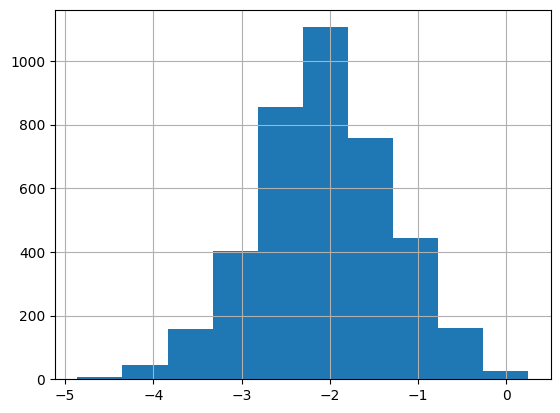

In [10]:
low_mass_satellite_df['avg_SFR'].hist()

In [11]:
# this indicates that there are more instances of the delta rate on the left

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

galaxy_ids = low_mass_satellite_df['subID']

feature_importances_list = []
feature_names = None
test_mses = []
train_mses = []


for seed in range(10):
    # split galaxies into 50% training and 50% testing
    unique_galaxies = np.unique(low_mass_satellite_df['subID'])
    train_galaxies, test_galaxies = train_test_split(unique_galaxies, test_size=0.5, random_state=seed)

    # assign spaxels based on galaxy split
    train_data = low_mass_satellite_df[low_mass_satellite_df['subID'].isin(train_galaxies)]
    test_data = low_mass_satellite_df[low_mass_satellite_df['subID'].isin(test_galaxies)]

    X_train, y_train = train_data.drop(columns=['avg_SFR', 'subID']), train_data['avg_SFR']
    X_test, y_test = test_data.drop(columns=['avg_SFR', 'subID']), test_data['avg_SFR']
    
    
    if feature_names is None:
        feature_names = X_train.columns.tolist()

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    param_grid = {
    'n_estimators': [100,200, 300, 400, 500],  
    'max_depth': [50, 100, 150, 200, 250],  
    'min_samples_split': [50, 100, 150],  
    'min_samples_leaf': [100, 200, 300, 400],  
    'max_features': [None], 
    'bootstrap': [True],
    }
    rf_regressor = RandomForestRegressor(random_state=seed, n_jobs=-1)
    cv = KFold(n_splits=5, shuffle=True, random_state=seed)

    random_search = RandomizedSearchCV(
    estimator=rf_regressor, 
    param_distributions=param_grid, 
    n_iter=10,
    cv=cv, 
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=seed,
    verbose=2)

    random_search.fit(X_train_scaled, y_train)

    best_rf_regressor = random_search.best_estimator_

    best_rf_regressor.fit(X_train_scaled, y_train)
    
    y_train_pred = best_rf_regressor.predict(X_train_scaled)
    y_test_pred = best_rf_regressor.predict(X_test_scaled)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_mses.append(train_mse)
    test_mses.append(test_mse)
    
    feature_importances_list.append(best_rf_regressor.feature_importances_)
#     print(random_search.best_params_)
    print(f"Run {seed+1}: Train MSE = {train_mse:.4f}, Test MSE = {test_mse:.4f}")

print("\nAverage MSE over 10 runs:")
print(f"Train MSE: Mean = {np.mean(train_mses):.4f}, Std = {np.std(train_mses):.4f}")
print(f"Test MSE:  Mean = {np.mean(test_mses):.4f}, Std = {np.std(test_mses):.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 1: Train MSE = 0.2819, Test MSE = 0.2937
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 2: Train MSE = 0.2658, Test MSE = 0.3078
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 3: Train MSE = 0.2892, Test MSE = 0.2867
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 4: Train MSE = 0.2708, Test MSE = 0.3046
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 5: Train MSE = 0.2872, Test MSE = 0.2844
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 6: Train MSE = 0.2747, Test MSE = 0.3018
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 7: Train MSE = 0.2829, Test MSE = 0.2933
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 8: Train MSE = 0.2930, Test MSE = 0.2753
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Run 9: Train MSE = 0.2774, Test MSE = 0.2974
Fitting 5 folds for each of 10 candidates, tot


=== Average Feature Importances ===
      Feature  Mean Importance   Std Dev
1  avg_s_mass         0.956845  0.009341
0   bin_radii         0.021366  0.008968
3      BHMass         0.006687  0.004705
2      s_mass         0.006127  0.002041
4       Mhalo         0.005516  0.005111
5    overdens         0.003459  0.003265


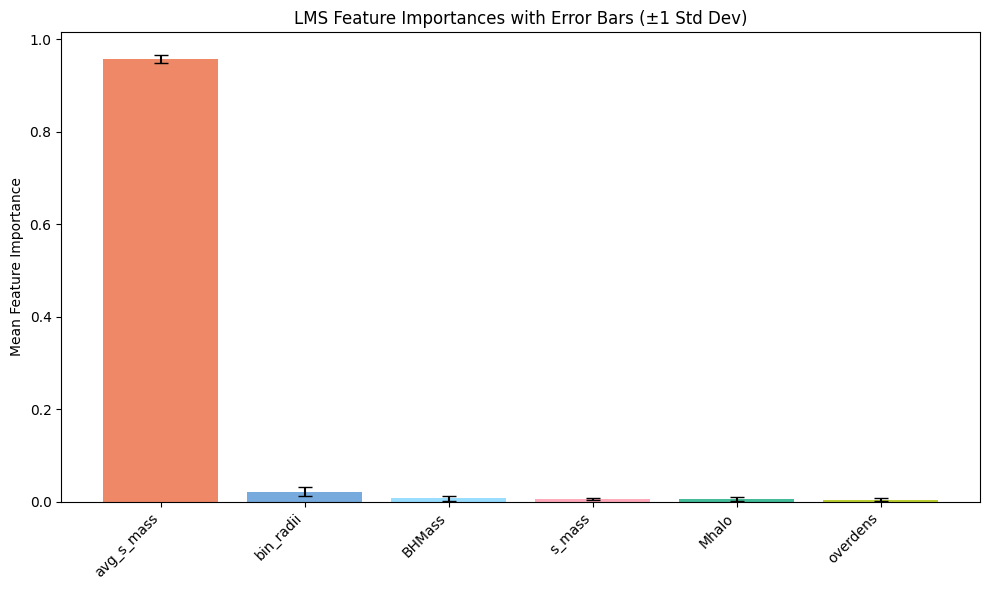

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
feature_colors = {
    'bin_radii': '#77AADD',
    'avg_s_mass': '#EE8866',
    # 'Bfld': '#EEDD88',
    # 'veldisp': '#CC3311',
    's_mass': '#FFAABB',
    'BHMass': '#99DDFF',
    'Mhalo': '#44BB99',
    'overdens': '#BBCC33',
    'bulge': '#AAAA00',
    'BH_AGN': '#DDDDDD',
}

# importances + stds across 10 runs
importances_array = np.array(feature_importances_list)
importance_means = np.mean(importances_array, axis=0)
importance_stds = np.std(importances_array, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': importance_means,
    'Std Dev': importance_stds
}).sort_values(by='Mean Importance', ascending=False)

print("\n=== Average Feature Importances ===")
print(importance_df)

colors = [feature_colors[feat] for feat in importance_df['Feature']]
# Plot
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Mean Importance'], yerr=importance_df['Std Dev'], capsize=5, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Feature Importance")
plt.title("LMS Feature Importances with Error Bars (±1 Std Dev)")
plt.tight_layout()
plt.show()

In [14]:
low_mass_satellite_df.corr()

,subID,bin_radii,avg_s_mass,avg_SFR,s_mass,BHMass,Mhalo,overdens
subID,1.000000,0.028881,-0.149387,-0.110800,-0.240204,-0.192119,-0.729958,-0.194620
bin_radii,0.028881,1.000000,-0.793152,-0.517114,-0.013869,-0.016820,-0.023238,-0.000882
avg_s_mass,-0.149387,-0.793152,1.000000,0.693531,0.389333,0.390791,0.091716,0.058867
avg_SFR,-0.110800,-0.517114,0.693531,1.000000,0.274866,0.267223,0.056873,0.091244
s_mass,-0.240204,-0.013869,0.389333,0.274866,1.000000,0.895213,0.105510,0.145470
BHMass,-0.192119,-0.016820,0.390791,0.267223,0.895213,1.000000,0.093729,0.079162
Mhalo,-0.729958,-0.023238,0.091716,0.056873,0.105510,0.093729,1.000000,0.098455
overdens,-0.194620,-0.000882,0.058867,0.091244,0.145470,0.079162,0.098455,1.000000


In [15]:
import os
# Define your directory and file name
directory = 'rf_regression_outputs'
filename = 'lms_rf_reg.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
importance_df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

DataFrame saved to rf_regression_outputs\lms_rf_reg.csv


In [16]:
train_mean = round(np.mean(train_mses), 2)
test_mean = round(np.mean(test_mses), 2)

df = pd.DataFrame({
    'Train MSE': [train_mean],
    'Test MSE': [test_mean]
})

print(df)
import os
# Define your directory and file name
directory = 'rf_regression_outputs'
filename = 'lms_rf_reg_mse.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

   Train MSE  Test MSE
0       0.28      0.29
DataFrame saved to rf_regression_outputs\lms_rf_reg_mse.csv
